# Load libraries

In [1]:
%reload_ext autoreload
%autoreload 2

import py4DSTEM
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import pickle
import os
import h5py
from py4DSTEM import show
from sklearn import cluster
from scipy.signal import fftconvolve
from scipy.spatial import distance
from scipy.ndimage import binary_dilation
from microstructure_inference.dataModules import cubic_proper_point_group_operations
from microstructure_inference.dataProcessing import point_in_spherical_triangle_oriented, assignment_cost_pairwise_distance,  sample_rotation_at_rand_geodesic_distance, _subtract_dog, generate_random_colormap
from skimage.transform import AffineTransform, warp
from matplotlib.colors import ListedColormap, BoundaryNorm
import random
import colorsys

print(py4DSTEM.__version__)
%autoreload 2

pixel_size_inv_Ang_guess = 0.0328
k_max = pixel_size_inv_Ang_guess * 64


0.14.8


In [28]:
def generate_colormap(class_label, syn_2D_scanSpace_map, class_0_colors, class_1_colors, num_colors=60, background_color="#ffffff"):
    """
    Generate a matplotlib ListedColormap with `num_colors` random colors,
    and optionally add a background color at index 0.
    
    Parameters:
        num_colors (int): Number of random colors (for grains).
        background_color (tuple): RGB tuple for background (index 0).
    
    Returns:
        ListedColormap: Colormap object for use in matplotlib.
    """
    # rng = np.random.default_rng(seed=12)  # For reproducibility
    # random_colors = rng.uniform(0.1, 0.9, size=(num_colors, 3))  # Avoid too dark/light

    # Prepend background color at index 0
    custom_colors = []
    custom_colors.append(background_color)
    class_0_color_grain_count = 0
    class_1_color_grain_count = 0
    
    for grain_index in range(1, int(np.max(syn_2D_scanSpace_map) + 1)):

        x_grain_idx, y_grain_idx = np.where(syn_2D_scanSpace_map==grain_index)


        # class 0 - Cu_fcc
        if np.average(class_label[x_grain_idx, y_grain_idx]) < 0.5:
            custom_colors.append(class_0_colors[class_0_color_grain_count])
            class_0_color_grain_count += 1
        else:

            custom_colors.append(class_1_colors[class_1_color_grain_count])
            class_1_color_grain_count += 1
        
    custom_colors_stacked = np.vstack([custom_colors])
    
    return ListedColormap(custom_colors)

def sample_colors(base_hex, n, hue_variation=0.04, light_variation=0.07, sat_variation=0.07):
    # Convert HEX to RGB
    base_rgb = tuple(int(base_hex[i:i+2], 16)/255 for i in (1,3,5))
    base_hls = colorsys.rgb_to_hls(*base_rgb)
    
    colors = []
    for _ in range(n):
        h = (base_hls[0] + random.uniform(-hue_variation, hue_variation)) % 1
        l = min(max(base_hls[1] + random.uniform(-light_variation, light_variation), 0), 1)
        s = min(max(base_hls[2] + random.uniform(-sat_variation, sat_variation), 0), 1)
        rgb = colorsys.hls_to_rgb(h, l, s)
        colors.append('#{:02X}{:02X}{:02X}'.format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255)))
    return colors

def return_angle_between_two_vectors_in_radian(vec_a, vec_b):

    normalized_vec_a = vec_a / np.linalg.norm(vec_a)
    normalized_vec_b = vec_b / np.linalg.norm(vec_b)
    
    # Calculate the dot product
    dot_product = np.dot(normalized_vec_a, normalized_vec_b)

    dot_product = np.clip(dot_product, -1.0, 1.0)
    
    # Calculate the angle in radians
    theta = np.arccos(dot_product)

    return theta


def calculate_probability_correct_by_disk_count(
    phase_predic,
    number_of_bragg_disks
):
    """
    Calculate the probability of a correct phase prediction, its
    standard error, and the number of diffraction patterns for each
    number of Bragg disks.

    Parameters
    ----------
    phase_predic : array-like
        Binary labels where 0 indicates a correct prediction and
        1 indicates an incorrect prediction.

    number_of_bragg_disks : array-like
        Number of Bragg disks associated with each diffraction pattern.

    Returns
    -------
    unique_disk_counts : numpy.ndarray
        Sorted unique numbers of Bragg disks.

    probability_correct : numpy.ndarray
        Probability of a correct phase prediction for each disk count.

    standard_error : numpy.ndarray
        Standard error of the estimated probability for each disk count.

    number_of_patterns : numpy.ndarray
        Number of diffraction patterns for each disk count.
    """
    phase_predic = np.asarray(phase_predic).ravel()
    number_of_bragg_disks = np.asarray(
        number_of_bragg_disks
    ).ravel()

    if phase_predic.size != number_of_bragg_disks.size:
        raise ValueError("The two arrays must have the same length.")

    valid = (
        np.isin(phase_predic, [0, 1])
        & np.isfinite(number_of_bragg_disks)
    )

    labels = phase_predic[valid]
    disk_counts = number_of_bragg_disks[valid].astype(int)

    if labels.size == 0:
        raise ValueError("No valid observations were found.")

    unique_disk_counts, number_of_patterns = np.unique(
        disk_counts,
        return_counts=True
    )

    probability_correct = []
    standard_error = []

    for n_disks, n_patterns in zip(
        unique_disk_counts,
        number_of_patterns
    ):
        selected = disk_counts == n_disks

        correct = labels[selected] == 0
        probability = np.mean(correct)

        error = np.sqrt(
            probability * (1.0 - probability) / n_patterns
        )

        probability_correct.append(probability)
        standard_error.append(error)

    return (
        unique_disk_counts,
        np.asarray(probability_correct),
        np.asarray(standard_error),
        number_of_patterns
    )

# Define custom functions

# Load data

# check output

In [3]:
model_path = os.getcwd() + "/"


trained_model_indicator_index = "multi_01"

supplementary_panel_path = model_path + "supplementaryFigure/"



# customPROBE = shifted_direct_beam_kernel / np.sum(shifted_direct_beam_kernel)
# customPROBE.shape
# datacube_aligned_data = py4DSTEM.DataCube(new_4d_tot)

In [4]:
data_path = "/home/kwang/Desktop/Storage/project/p03_orientation_mapping/figure/figure_04_and_05/"

filepath_braggdisks_cal = '/home/kwang/Desktop/Storage/project/p03_orientation_mapping/figure/figure_04_and_05/bragg_disks_corThForK80000_dog_sig1_2.00_sig2_6.00_cortThForTemp_14000.h5'
# py4DSTEM.save(
#     filepath_braggdisks_cal,
#     bragg_peaks,
#     mode='o',
# )

bragg_peaks = py4DSTEM.read(
    filepath_braggdisks_cal, 
)

Reading PointListArray: 100%|███| 38400/38400 [00:02<00:00, 16497.90PointList/s]


In [8]:
Rx, Ry = int(bragg_peaks.shape[0]), int(bragg_peaks.shape[1])

In [5]:
scan_indices = []
Number_of_Bragg_disks = []
table_BPs_scanIndex = {}
dict_idx = 0
for i in range(bragg_peaks.shape[0]):
    for j in range(bragg_peaks.shape[1]):
        if len(bragg_peaks.cal[i,j].qx) > 2:

            qx = np.copy(bragg_peaks.cal[i,j].data["qx"])
            qy = np.copy(bragg_peaks.cal[i,j].data["qy"])
            intensity = np.copy(bragg_peaks.cal[i,j].data["intensity"] / np.max(bragg_peaks.cal[i,j].data["intensity"]))

            k_radial_distnaces_of_BPs = np.linalg.norm(np.stack((qx, qy)).T, axis = 1)
            index_of_direct_beam = np.argmin(k_radial_distnaces_of_BPs)

            qx = np.delete(qx, index_of_direct_beam)
            qy = np.delete(qy, index_of_direct_beam)
            intensity = np.delete(intensity, index_of_direct_beam)



            positions_of_bragg_peaks = np.stack((qx, qy)).T
            k_radial_distnaces_of_BPs = np.linalg.norm(positions_of_bragg_peaks, axis = 1)
            polar_angles = np.arctan2(positions_of_bragg_peaks[:,1], positions_of_bragg_peaks[:,0])


            table_BPs_scanIndex[dict_idx] = {'input': np.stack((k_radial_distnaces_of_BPs, polar_angles, intensity)).T, 'scanIndices': [i,j]}

            scan_indices.append([i,j])
            Number_of_Bragg_disks.append(len(qx))

            dict_idx += 1


scan_indices = np.array(scan_indices)
Number_of_Bragg_disks = np.array(Number_of_Bragg_disks)

In [6]:
k_max = 0.0328 * 64 * np.sqrt(2)
accelerating_voltage = int(300e3)
crystal = py4DSTEM.process.diffraction.Crystal.from_CIF(data_path + "Cu_fcc.cif")
crystal.setup_diffraction(accelerating_voltage)
crystal.calculate_structure_factors(
    k_max,
)

# Create an orientation plan for [0001] WS2
crystal.orientation_plan(
    angle_step_zone_axis = 2,
    angle_step_in_plane = 2,
    accel_voltage = 300e3,
    corr_kernel_size=0.08, # was 0.08 before 0.12 not bad
    zone_axis_range='auto',
)

Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.
self.orientation_refine
 False 



Orientation plan: 100%|█████████████| 406/406 [00:00<00:00, 2271.44 zone axes/s]


In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Fri May 23 14:49:36 2025

@author: kwang
"""

import py4DSTEM
import numpy as np
import time
from microstructure_inference.transformerModel import ModelConfig, make_model
import torch
from torch.utils.data import DataLoader
import pandas as pd
import argparse
from microstructure_inference.dataProcessing import pre_process_experimental_BraggDisk, pre_process_synthetic_4DSTEM, process_pandas_tabular_data, predict_rotation_and_phase_experimental_data, make_orientation_map_based_on_4D_rotation_matrices
from microstructure_inference.dataModules import ExpDataset
print("py4DSTEM version: ", py4DSTEM.__version__)



    
start_perf = time.perf_counter()


num_bins_radialDistance = 256
num_bins_polarAngle = 360
num_bins_braggintensity = 64

# scan_dim = 128
# input_path = str(args.input_path)
input_path = "./"
output_path = "./"
PAD = 0

isMultitask = 1

embed_dim = 384
max_sequence_length = 106

max_radial_distance = 2.99000

max_braggIntensity = 1.0

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

number_of_pixels_in_one_dimension = 120
k_max = 0.0328 * number_of_pixels_in_one_dimension / 2
accelerating_voltage = int(300e3)
crystal = py4DSTEM.process.diffraction.Crystal.from_CIF(data_path + "Cu_fcc.cif")
crystal.setup_diffraction(accelerating_voltage)
crystal.calculate_structure_factors(k_max)

crystal.orientation_plan(
                        angle_step_zone_axis = 2,
                        accel_voltage = accelerating_voltage,
                        zone_axis_range = 'auto',
                        )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # <--- CHANGED: fallback to CPU if no GPU
print(f"Using device: {device}")  # <--- ADDED: print device

end_perf = time.perf_counter()
elapsed_perf = end_perf - start_perf

print(f"setting parameters and initialzing crystal object: {elapsed_perf:.6f} seconds\n")



start_perf = time.perf_counter()




# file_name = "synthetic_bragg_vector_point_list_scan_space_dimension_%d_uncal"%(scan_dim)
# bragg_peaks = py4DSTEM.read(input_path + file_name + ".h5")

end_perf = time.perf_counter()
elapsed_perf = end_perf - start_perf

print("")

print(f"reading Bragg disk list: {elapsed_perf:.6f} seconds\n")

start_perf = time.perf_counter()

# table_of_BraggDisk_qx_qy_intensity_for_eachScanIndex = pre_process_synthetic_4DSTEM(bragg_peaks, scan_indices)

table_of_BraggDisk_qx_qy_intensity_for_eachScanIdx = pre_process_experimental_BraggDisk(bragg_peaks)

df = pd.DataFrame(table_of_BraggDisk_qx_qy_intensity_for_eachScanIdx)
# df.to_json(procssed_data_saving_path + trained_model_indicator_index + "_" + Bragg_vector_file_name + '_preProcessed_df.json', index=True)



(list_of_bragg_peaks_total, \
 radial_bins, radial_bin_centers, \
 angle_bins, angle_bin_centers, \
 intensity_bins, intensity_bin_centers) = process_pandas_tabular_data(
                                                 df, 
                                                 num_bins_radialDistance, 
                                                 num_bins_polarAngle, 
                                                 num_bins_braggintensity, 
                                                 max_sequence_length,
                                                 max_radial_distance,
                                                 max_braggIntensity)



del table_of_BraggDisk_qx_qy_intensity_for_eachScanIdx


###############################################################################
######## STEP 1. ADD [PAD] tokens and SHUFFLE processed data

list_of_bragg_peaks_total = torch.nn.utils.rnn.pad_sequence(
                                                    list_of_bragg_peaks_total, 
                                                    batch_first=True, 
                                                    padding_value = PAD)


del df

end_perf = time.perf_counter()
elapsed_perf = end_perf - start_perf

print(f"change coordinate and make torch tensor: {elapsed_perf:.6f} seconds\n")

start_perf = time.perf_counter()
experimental_dataset = ExpDataset(list_of_bragg_peaks_total, transform = None)

exp_loader = DataLoader(
                        experimental_dataset,
                        batch_size = 2048,
                        shuffle = False,
                        pin_memory=torch.cuda.is_available(),                        
                         )

config = ModelConfig(
                     d_embed = embed_dim,
                     d_ff = 2 * embed_dim,
                     angle_bin_centers = angle_bin_centers,
                     intensity_bin_centers = intensity_bin_centers,
                     num_bins_radialDistance = num_bins_radialDistance,
                     device = device,
                     num_feature = 9,
                     h = 8,
                     N_encoder = 3,
                     max_seq_len = max_sequence_length,
                     dropout = 0.001,
                     multiTask = isMultitask,
                     )

model = make_model(config)


# checkpoint = torch.load('best_model_with_transform.pth') # ie, model_best.pth.tar
checkpoint = torch.load(model_path + 'multi_01.pth', map_location=device) # ie, model_best.pth.tar
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

end_perf = time.perf_counter()
elapsed_perf = end_perf - start_perf

print(f"Time for loading models and setting dataloader: {elapsed_perf:.6f} seconds\n")

start_perf = time.perf_counter()

with torch.no_grad():
    rotation_matrices_predicted, phase_label = predict_rotation_and_phase_experimental_data(model, exp_loader, device)

end_perf = time.perf_counter()
elapsed_perf = end_perf - start_perf
print(f"Time for predicting orientations time: {elapsed_perf:.6f} seconds\n")

start_perf = time.perf_counter()    
rotation_matrices_predicted_np = rotation_matrices_predicted.detach().cpu().numpy()
phase_label_np = phase_label.detach().cpu().numpy()
del rotation_matrices_predicted

# print("rotation_matrices_predicted_np.shape", rotation_matrices_predicted_np.shape)




phase_label_4D = np.ones((Rx, Ry), dtype = np.int64) * int(2)
rotation_matrices_predicted_np_4D = np.zeros((Rx, Ry, 3, 3))



for sampled_data_count, scan_index in enumerate(scan_indices):
    i = scan_index[0]
    j = scan_index[1]
    rotation_matrices_predicted_np_4D[i,j] = rotation_matrices_predicted_np[sampled_data_count]
    phase_label_4D[i,j] = int(phase_label_np[sampled_data_count][0])
    


orientation_Map_model_prediction = make_orientation_map_based_on_4D_rotation_matrices(rotation_matrices_predicted_np_4D, crystal)

np.save(model_path + "multiple_crystal_4DSTEM_mapping_result_orientation_predictions.npy", rotation_matrices_predicted_np_4D)
np.save(model_path + "multiple_crystal_4DSTEM_mapping_result_phase_predictions.npy", phase_label_4D)

pickle_filename = output_path + 'multiple_crystal_synthetic_4DSTEM_orientation_map.pkl'

# Save the object
with open(pickle_filename, 'wb') as f:
    pickle.dump(orientation_Map_model_prediction, f)

torch.cuda.empty_cache()
# del model, exp_loader, rotation_matrices_predicted_np, orientation_Map


end_perf = time.perf_counter()
elapsed_perf = end_perf - start_perf
print(f"making orientation map: {elapsed_perf:.6f} seconds\n")



py4DSTEM version:  0.14.8
Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.
self.orientation_refine
 False 



Orientation plan: 100%|█████████████| 406/406 [00:00<00:00, 6211.27 zone axes/s]

Using device: cuda
setting parameters and initialzing crystal object: 0.098235 seconds


reading Bragg disk list: 0.000007 seconds



change coordinate and make torch tensor: 2.324605 seconds

intensity_bin_centers.shape[0]
 64 

Time for loading models and setting dataloader: 0.036461 seconds

Time for predicting orientations time: 0.575520 seconds

making orientation map: 0.911722 seconds



In [9]:
list_of_bragg_peaks_total.shape, scan_indices.shape

(torch.Size([8889, 106, 3]), (8889, 2))

# phase prediction accuracy

In [10]:
from microstructure_inference.dataProcessing import pre_process_experimental_BraggDisk, pre_process_synthetic_4DSTEM, process_pandas_tabular_data, predict_rotation_and_phase_experimental_data, make_orientation_map_based_on_4D_rotation_matrices

k_max = 0.0328 * 64
accelerating_voltage = int(300e3)
crystal = py4DSTEM.process.diffraction.Crystal.from_CIF(data_path + "Cu_fcc.cif")
crystal.setup_diffraction(accelerating_voltage)
crystal.calculate_structure_factors(
    k_max,
)

# Create an orientation plan for [0001] WS2
crystal.orientation_plan(
    angle_step_zone_axis = 2,
    angle_step_in_plane = 2,
    accel_voltage = 300e3,
    corr_kernel_size=0.08, # was 0.08 before 0.12 not bad
    zone_axis_range='auto',
)

phase_predi_4D = np.load(model_path + "multiple_crystal_4DSTEM_mapping_result_phase_predictions.npy")
rotation_matrices_predicted_np_4D = np.load(model_path + "multiple_crystal_4DSTEM_mapping_result_orientation_predictions.npy")
import pickle

pickle_filename = model_path + 'multiple_crystal_synthetic_4DSTEM_orientation_map.pkl'
with open(pickle_filename, 'rb') as f:
    orientation_Map_model_prediction = pickle.load(f)

# Now you can use the loaded object
print(orientation_Map_model_prediction)

filepath_braggdisks_cal ='/home/kwang/Desktop/Storage/project/p03_orientation_mapping/figure/figure_04_and_05/bragg_disks_corThForK80000_dog_sig1_2.00_sig2_6.00_cortThForTemp_14000.h5'
# py4DSTEM.save(
#     filepath_braggdisks_cal,
#     bragg_peaks,
#     mode='o',
# )

bragg_peaks = py4DSTEM.read(
    filepath_braggdisks_cal, 
)

orientation_Map_model_prediction = make_orientation_map_based_on_4D_rotation_matrices(rotation_matrices_predicted_np_4D, crystal)

Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.
self.orientation_refine
 False 



Orientation plan: 100%|█████████████| 406/406 [00:00<00:00, 5045.62 zone axes/s]


OrientationMap(num_x=256, num_y=150, num_matches=1)


Reading PointListArray: 100%|███| 38400/38400 [00:02<00:00, 16417.91PointList/s]


In [11]:
phase_label = []
phase_predic = []

for scan_index in scan_indices:
    xind = scan_index[0]
    yind = scan_index[1]

    phase_predic.append(phase_predi_4D[xind,yind])
    phase_label.append(int(0))

phase_predic = np.array(phase_predic, dtype = np.int64)
phase_label = np.array(phase_label, dtype = np.int64)
print("phase_predic.shape", phase_predic.shape)
print("phase_label.shape", phase_label.shape)
print("np.max(phase_predic), np.min(phase_predic)", np.max(phase_predic),np.min(phase_predic))
print("np.max(phase_label), np.min(phase_label)", np.max(phase_label), np.min(phase_label))
accuracy = np.mean(phase_label == phase_predic)
print("phase prediction accuracy:", accuracy)

N = len(phase_label)
p = accuracy

std_accuracy = np.sqrt(p * (1 - p) / N)
print("Std of accuracy:", std_accuracy)

correct = (phase_label == phase_predic).astype(int)
N = len(correct)

n_boot = 1000
boot_acc = []

for _ in range(n_boot):
    sample = np.random.choice(correct, size=N, replace=True)
    boot_acc.append(np.mean(sample))

boot_acc = np.array(boot_acc)

print("Accuracy:", np.mean(boot_acc))
print("Std (bootstrap):", np.std(boot_acc))

phase_predic.shape (8889,)
phase_label.shape (8889,)
np.max(phase_predic), np.min(phase_predic) 1 0
np.max(phase_label), np.min(phase_label) 0 0
phase prediction accuracy: 0.7994150073124086
Std of accuracy: 0.004247260648556279
Accuracy: 0.7993251209359884
Std (bootstrap): 0.00430834746820005


In [12]:
counts_phase_label = np.bincount(phase_label_4D.ravel())
counts_phase_label[0] / (counts_phase_label[0] + counts_phase_label[1])

np.float64(0.7994150073124086)

In [15]:
np.unique(phase_predic)

array([0, 1])

In [14]:
Number_of_Bragg_disks

array([4, 6, 4, ..., 2, 5, 5], shape=(8889,))

In [16]:
phase_predic

array([0, 0, 0, ..., 0, 0, 0], shape=(8889,))

In [36]:
Number_of_Bragg_disks[-1]

np.int64(5)

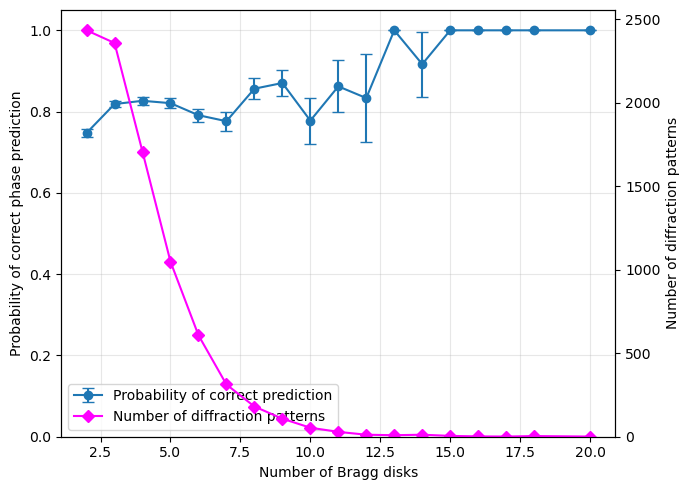

In [35]:
(
    unique_disk_counts,
    probability_correct,
    standard_error,
    number_of_patterns
) = calculate_probability_correct_by_disk_count(
    phase_predic,
    Number_of_Bragg_disks
)

fig, ax_left = plt.subplots(figsize=(7, 5))

# Left y-axis: probability of correct prediction
probability_plot = ax_left.errorbar(
    unique_disk_counts,
    probability_correct,
    yerr=standard_error,
    marker="o",
    linestyle="-",
    capsize=4,
    label="Probability of correct prediction"
)

ax_left.set_xlabel("Number of Bragg disks")
ax_left.set_ylabel("Probability of correct phase prediction")
ax_left.set_ylim(0, 1.05)
ax_left.grid(alpha=0.3)

# Right y-axis: number of diffraction patterns
ax_right = ax_left.twinx()

count_plot, = ax_right.plot(
    unique_disk_counts,
    number_of_patterns,
    marker="D",
    linestyle="-",
    color="#ff00ff",
    label="Number of diffraction patterns"
)

ax_right.set_ylabel("Number of diffraction patterns")
ax_right.set_ylim(bottom=0)

# Combined legend
handles_left, labels_left = ax_left.get_legend_handles_labels()
handles_right, labels_right = ax_right.get_legend_handles_labels()

ax_left.legend(
    handles_left + handles_right,
    labels_left + labels_right,
    loc="best"
)

plt.tight_layout()
plt.show()

np.savez(
    trained_model_indicator_index
    + "_phase_prediction_probability_by_bragg_disks.npz",
    unique_disk_counts=unique_disk_counts,
    probability_correct=probability_correct,
    standard_error=standard_error,
    number_of_patterns=number_of_patterns
)

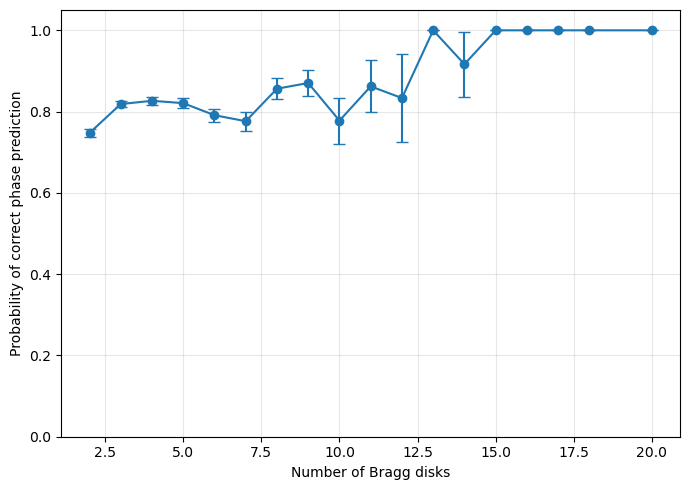

In [25]:
(unique_disk_counts,probability_correct,standard_error,number_of_patterns) = calculate_probability_correct_by_disk_count(
    phase_predic,
    Number_of_Bragg_disks
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    unique_disk_counts,
    probability_correct,
    yerr=standard_error,
    marker="o",
    linestyle="-",
    capsize=4
)

ax.set_xlabel("Number of Bragg disks")
ax.set_ylabel("Probability of correct phase prediction")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

np.savez(
    trained_model_indicator_index + "_phase_prediction_probability_by_bragg_disks.npz",
    unique_disk_counts=unique_disk_counts,
    probability_correct=probability_correct,
    standard_error=standard_error
)

In [24]:
unique_disk_counts, probability_correct, standard_error

(array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        20]),
 array([0.74743326, 0.81856719, 0.82659637, 0.8207817 , 0.79111842,
        0.77635783, 0.85635359, 0.87037037, 0.77777778, 0.86206897,
        0.83333333, 1.        , 0.91666667, 1.        , 1.        ,
        1.        , 1.        , 1.        ]),
 array([0.00880491, 0.00793453, 0.00916345, 0.01184179, 0.01648614,
        0.02355243, 0.02606962, 0.03232156, 0.05657501, 0.06403288,
        0.10758287, 0.        , 0.07978559, 0.        , 0.        ,
        0.        , 0.        , 0.        ]))

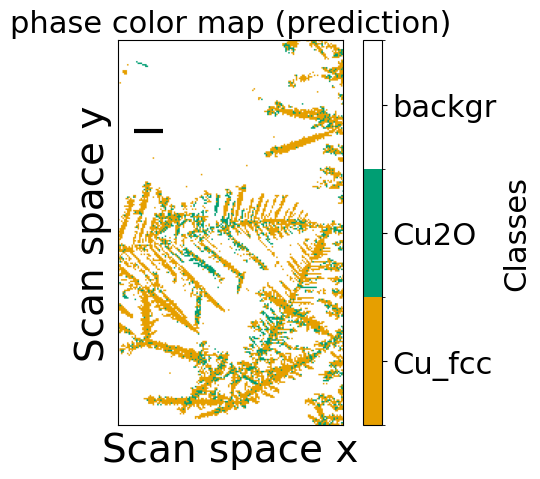

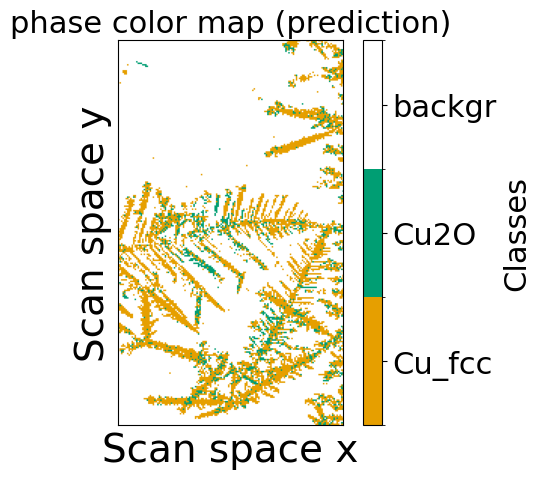

In [13]:

class_labels = ['Cu_fcc', 'Cu2O','backgr']
tick_positions = [0.5, 1.5, 2.5]

phase_class_color_map = ListedColormap(["#E69F00", "#009E73", "#ffffff"])
phase_class_color_bounds = np.array([0, 1, 2, 3])
phase_class_color_norm = BoundaryNorm(phase_class_color_bounds, 3)
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.set_title("phase color map (prediction)", fontsize=22)
im = ax.imshow(phase_label_4D, cmap=phase_class_color_map, norm=phase_class_color_norm, rasterized=True)
# Set axis labels

ax.set_xticks([])
ax.set_yticks([])

# ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=28)
# ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=28)
# ax.set_xticks([0, 40, 80, 120])
# ax.set_yticks([0, 40, 80, 120])
ax.set_xlabel(r"Scan space x", fontsize = 28)
ax.set_ylabel(r"Scan space y", fontsize = 28)

# Add the colorbar with custom ticks and labels
cbar = fig.colorbar(im, ax=ax, fraction=0.05, ticks=phase_class_color_bounds)
# Set custom ticks and labels on the colorbar
cbar.set_ticks(tick_positions)
cbar.set_ticklabels(class_labels, fontsize=22)
cbar.set_label("Classes", fontsize=22)

scan_space_pixel_spacing_nm = 20.2 #[nm]
bar_length_nm = 400 #[nm]
bar_length_pixel = bar_length_nm / scan_space_pixel_spacing_nm

scale_bar_y = 60
scale_bar_x_start = 10
scale_bar_x_end = scale_bar_x_start + bar_length_pixel
plt.plot([scale_bar_x_start, scale_bar_x_end],[scale_bar_y, scale_bar_y], color = "k", lw=3, solid_capstyle="butt")


plt.savefig(supplementary_panel_path + trained_model_indicator_index +  "_phase_color_map_prediction_with_scale_bar.png", bbox_inches='tight', facecolor='white', edgecolor='none',dpi = 300,transparent=False)
plt.savefig(supplementary_panel_path + trained_model_indicator_index +  "_phase_color_map_prediction_with_scale_bar.pdf", bbox_inches='tight', facecolor='white', edgecolor='none',dpi = 300,transparent=False)
plt.savefig(supplementary_panel_path + trained_model_indicator_index +  "_phase_color_map_prediction_with_scale_bar.svg", bbox_inches='tight', facecolor='white', edgecolor='none',dpi = 300,transparent=False)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.set_title("phase color map (prediction)", fontsize=22)
im = ax.imshow(phase_label_4D, cmap=phase_class_color_map, norm=phase_class_color_norm, rasterized=True)
# Set axis labels

ax.set_xticks([])
ax.set_yticks([])

# ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=28)
# ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=28)
# ax.set_xticks([0, 40, 80, 120])
# ax.set_yticks([0, 40, 80, 120])
ax.set_xlabel(r"Scan space x", fontsize = 28)
ax.set_ylabel(r"Scan space y", fontsize = 28)

# Add the colorbar with custom ticks and labels
cbar = fig.colorbar(im, ax=ax, fraction=0.05, ticks=phase_class_color_bounds)
# Set custom ticks and labels on the colorbar
cbar.set_ticks(tick_positions)
cbar.set_ticklabels(class_labels, fontsize=22)
cbar.set_label("Classes", fontsize=22)

plt.savefig(supplementary_panel_path + trained_model_indicator_index +  "_phase_color_map_prediction.png", bbox_inches='tight', facecolor='white', edgecolor='none',dpi = 300,transparent=False)
plt.savefig(supplementary_panel_path + trained_model_indicator_index +  "_phase_color_map_prediction.pdf", bbox_inches='tight', facecolor='white', edgecolor='none',dpi = 300,transparent=False)
plt.savefig(supplementary_panel_path + trained_model_indicator_index +  "_phase_color_map_prediction.svg", bbox_inches='tight', facecolor='white', edgecolor='none',dpi = 300,transparent=False)
plt.show()

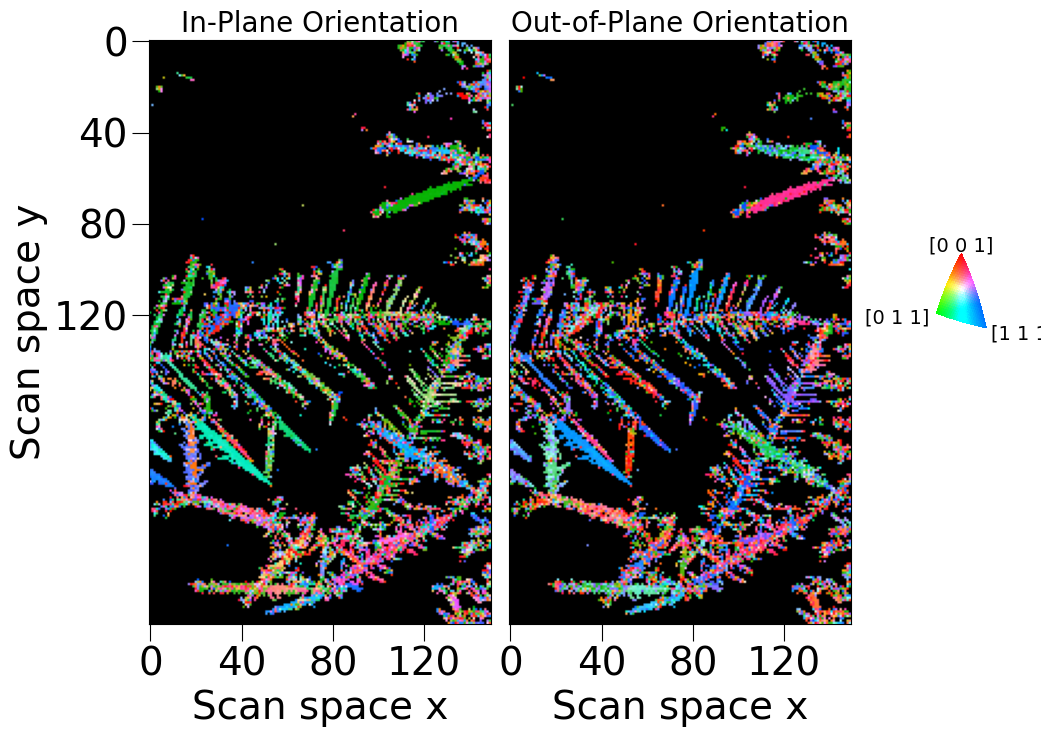

In [14]:
# orientation_Map_model_ground_truth = make_orientation_map_based_on_4D_rotation_matrices(orient_tot, crystal)

# images_orientation_ground_truth, fig_ground_truth, ax_ground_truth = crystal.plot_orientation_maps(
#     orientation_Map_model_ground_truth,
#     # orientation_ind=0,
#     # symmetry_order = 6,
#     corr_range = [0.9, 1.0],
#     figsize = (9,9),
#     returnfig = True,
# )


# ax_ground_truth[0].tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=28)
# ax_ground_truth[0].tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=28)
# ax_ground_truth[0].set_xticks([0, 40, 80, 120])
# ax_ground_truth[0].set_yticks([0, 40, 80, 120])
# ax_ground_truth[0].set_xlabel(r"Scan space x", fontsize = 28)
# ax_ground_truth[0].set_ylabel(r"Scan space y", fontsize = 28)

# ax_ground_truth[1].tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=28)
# ax_ground_truth[1].tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=28)
# ax_ground_truth[1].set_xticks([0, 40, 80, 120])
# ax_ground_truth[1].set_yticks([0, 40, 80, 120])
# ax_ground_truth[1].set_xlabel(r"Scan space x", fontsize = 28)
# ax_ground_truth[1].set_ylabel(r"Scan space y", fontsize = 28)


# ax_ground_truth[1].set_yticks([])
# ax_ground_truth[1].set_ylabel("")

# fig_ground_truth.savefig(panel_d_f_path + trained_model_indicator_index + "_orientation_color_map_ground_truth.pdf", bbox_inches='tight', dpi = 300)
# fig_ground_truth.savefig(panel_d_f_path + trained_model_indicator_index + "_orientation_color_map_ground_truth.png", bbox_inches='tight', dpi = 300)
# plt.show()


images_orientation_pred, fig_pred, ax_pred = crystal.plot_orientation_maps(
    orientation_Map_model_prediction,
    # orientation_ind=0,
    # symmetry_order = 6,
    corr_range = [0.9, 1.0],
    figsize = (9,9),
    returnfig = True,
)

ax_pred[0].tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax_pred[0].tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax_pred[0].set_xticks([0, 40, 80, 120])
ax_pred[0].set_yticks([0, 40, 80, 120])
ax_pred[0].set_xlabel(r"Scan space x", fontsize = 28)
ax_pred[0].set_ylabel(r"Scan space y", fontsize = 28)

ax_pred[1].tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax_pred[1].tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax_pred[1].set_xticks([0, 40, 80, 120])
ax_pred[1].set_yticks([0, 40, 80, 120])
ax_pred[1].set_xlabel(r"Scan space x", fontsize = 28)
ax_pred[1].set_ylabel(r"Scan space y", fontsize = 28)


ax_pred[1].set_yticks([])
ax_pred[1].set_ylabel("")

plt.savefig(supplementary_panel_path + trained_model_indicator_index +  "_orientation_color_map_prediction.png", bbox_inches='tight', facecolor='white', edgecolor='none',dpi = 300,transparent=False)
plt.savefig(supplementary_panel_path + trained_model_indicator_index +  "_orientation_color_map_prediction.pdf", bbox_inches='tight', facecolor='white', edgecolor='none',dpi = 300,transparent=False)
plt.savefig(supplementary_panel_path + trained_model_indicator_index +  "_orientation_color_map_prediction.svg", bbox_inches='tight', facecolor='white', edgecolor='none',dpi = 300,transparent=False)

# fig_pred.savefig(panel_d_f_path + trained_model_indicator_index + "_orientation_color_map_pred.pdf", bbox_inches='tight', dpi = 300)
# fig_pred.savefig(panel_d_f_path + trained_model_indicator_index + "_orientation_color_map_pred.png", bbox_inches='tight', dpi = 300)
plt.show()
